### 1) Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os,cv2
from sklearn.model_selection import train_test_split 
from sklearn.utils import shuffle
import tensorflow as tf
# from keras.applications import ResNet50
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import datasets,layers,models


### 2) Classes Labeling

In [5]:
Class_names=['no_tumor','glioma','meningioma','pituitary']
Class_names_encoder={class_name:i for i,class_name in enumerate(Class_names)}
classes_num=len(Class_names_encoder)
classes_num,Class_names_encoder


(4, {'no_tumor': 0, 'glioma': 1, 'meningioma': 2, 'pituitary': 3})

### 3) Important PreDefine 

In [8]:
IMAGE_SIZE=(224,224)

### 4)Data Reading

In [11]:
datasets=[r'brisc2025/classification_task/train',
         r'brisc2025/classification_task/test']
output=[]
for dataset in datasets:
    images=[]
    labels=[]
    for folder in os.listdir(dataset):
        label=Class_names_encoder[folder]
        folderpath=os.path.join(dataset,folder)
        imagesoffolder=os.listdir(folderpath)
        for i in range(len(imagesoffolder)):
            imagepath=os.path.join(folderpath,imagesoffolder[i])
            image=cv2.imread(imagepath)
            image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
            image=cv2.resize(image,IMAGE_SIZE)
            images.append(image)
            labels.append(label)
    images=np.array(images)
    labels=np.array(labels)
    output.append((images,labels))

### 5)Checks

In [14]:
#  training data
len(output[0][1]),len(output[0][0])

(5000, 5000)

In [16]:
# testing data
len(output[1][1]),len(output[1][0])

(1000, 1000)

In [18]:
output[0][0].shape,output[1][0].shape

((5000, 224, 224, 3), (1000, 224, 224, 3))

### 6) Data Spliting

In [21]:
Train_images=output[0][0]
Train_labels=output[0][1]
Test_images=output[1][0]
Test_labels=output[1][1]

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    Train_images,
    Train_labels,
    test_size=0.2,
    stratify=Train_labels,
    random_state=42,
    shuffle=True
)

### 7)Visualization

In [26]:
pd.Series(y_train).value_counts()

3    1165
2    1063
1     918
0     854
Name: count, dtype: int64

In [28]:
invClass_names_encoder={i:class_name for i,class_name in enumerate(Class_names)}
invClass_names_encoder

{0: 'no_tumor', 1: 'glioma', 2: 'meningioma', 3: 'pituitary'}

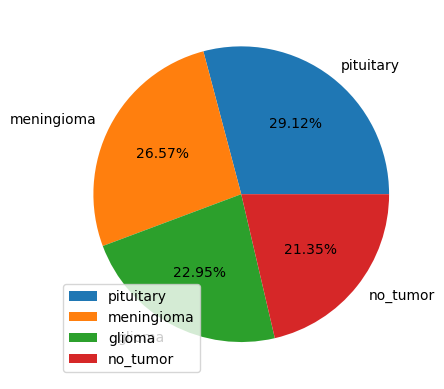

In [30]:
plt.pie(pd.Series(y_train).value_counts(),labels=[invClass_names_encoder[i] for i in pd.Series(y_train).value_counts().index],autopct='%0.2f%%')
plt.legend()
plt.show()

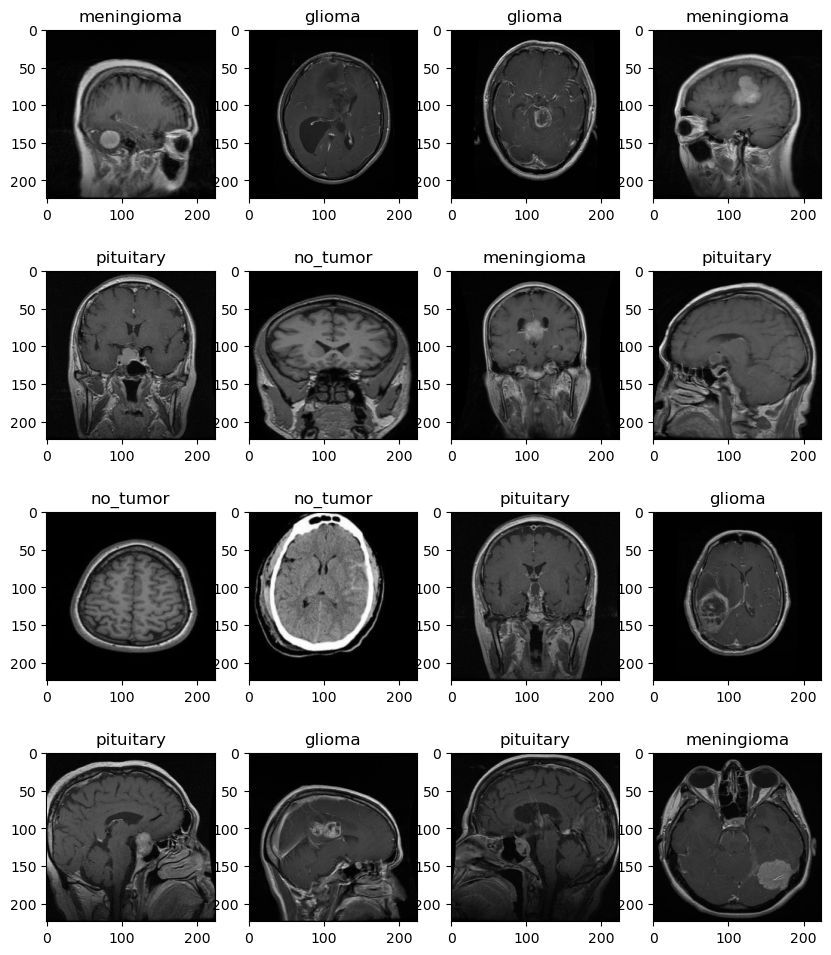

In [32]:
plt.figure(figsize=(10,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.title(invClass_names_encoder[y_train[i]])
    plt.imshow(X_train[i])
plt.show()

In [34]:
X_train   = preprocess_input(X_train.astype("float32"))
X_val   = preprocess_input(X_val.astype("float32"))
Test_images = preprocess_input(Test_images.astype("float32"))

In [36]:
datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

In [38]:
Train_generator = datagen.flow(X_train, y_train, batch_size=64)

In [62]:
model=tf.keras.models.Sequential()
model.add(MobileNetV2(weights='imagenet',input_shape=(224,224,3),pooling='avg',include_top=False))
tf.keras.layers.Dropout(0.5),
tf.keras.layers.Dense(128, activation='relu'),
tf.keras.layers.Dropout(0.3),
model.add(tf.keras.layers.Dense(4,activation='softmax'))

In [64]:
# model=models.Sequential()
# model.add(layers.Conv2D(32,kernel_size=(3,3),strides=(1,1),padding='same',input_shape=(200,200,3),activation='relu'))
# model.add(layers.MaxPooling2D((2,2),strides=(2,2)))
# model.add(layers.Conv2D(64,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
# model.add(layers.MaxPooling2D((2,2),strides=(2,2)))
# model.add(layers.Conv2D(64,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
# model.add(layers.MaxPooling2D((2,2),strides=(2,2)))
# model.add(layers.Flatten())
# model.add(layers.Dense(128,activation='relu'))
# model.add(layers.Dropout(0.3))
# model.add(layers.Dense(64,activation='relu'))
# model.add(layers.Dense(4,activation='softmax'))

In [66]:
base_model = model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

In [68]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    # optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,           
    patience=3,           
    min_lr=1e-6           
)

In [72]:
early_stoping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=5,
                                                    restore_best_weights=True)

In [74]:
history=model.fit(Train_generator,epochs=15,verbose=1,validation_data = (X_val, y_val),
                     callbacks= [early_stoping,lr_scheduler])

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7104 - loss: 0.7235 - val_accuracy: 0.4460 - val_loss: 1.5280 - learning_rate: 1.0000e-04
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9491 - loss: 0.1563 - val_accuracy: 0.5970 - val_loss: 1.1465 - learning_rate: 1.0000e-04
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9734 - loss: 0.0828 - val_accuracy: 0.7470 - val_loss: 0.6448 - learning_rate: 1.0000e-04
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9920 - loss: 0.0410 - val_accuracy: 0.8800 - val_loss: 0.3202 - learning_rate: 1.0000e-04
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9949 - loss: 0.0260 - val_accuracy: 0.8960 - val_loss: 0.3152 - learning_rate: 1.0000e-04
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9943 - loss: 0.0215 - val_accuracy: 0.9130 - val_loss: 0.2437 - learning_rate: 1.0000e-04
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9952 

In [76]:
test_loss, test_acc = model.evaluate(Test_images, Test_labels)
print(test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 370ms/step - accuracy: 0.9106 - loss: 0.2381
0.9269999861717224


In [78]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,636,046 (21.50 MB)

 Trainable params: 1,686,468 (6.43 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 3,372,938 (12.87 MB)

In [80]:
pred = model.predict(Test_images)
pred = np.argmax(pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 437ms/step


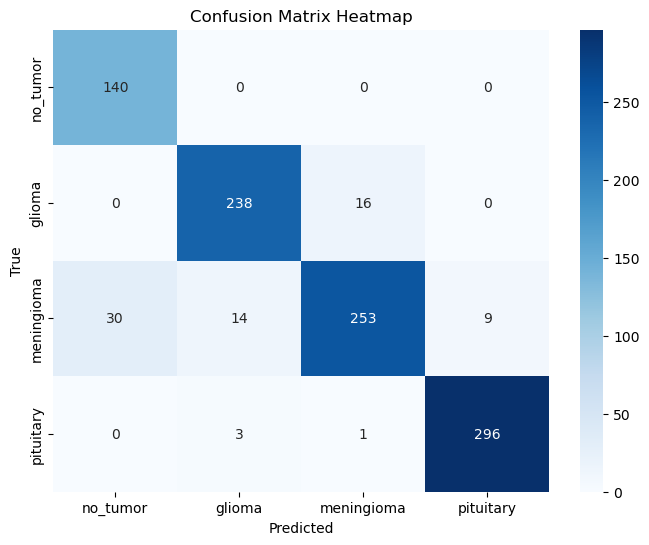

In [82]:
cm=confusion_matrix(Test_labels,pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=Class_names, yticklabels=Class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [84]:
print(classification_report(Test_labels,pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       140
           1       0.93      0.94      0.94       254
           2       0.94      0.83      0.88       306
           3       0.97      0.99      0.98       300

    accuracy                           0.93      1000
   macro avg       0.92      0.94      0.92      1000
weighted avg       0.93      0.93      0.93      1000



C:\Users\sh\AppData\Local\Temp\ipykernel_7672\868731250.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


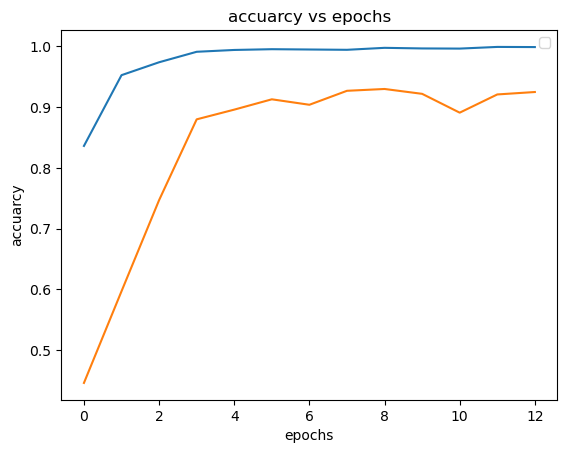

In [86]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuarcy')
plt.title('accuarcy vs epochs')
plt.legend()
plt.show()

C:\Users\sh\AppData\Local\Temp\ipykernel_7672\518395082.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


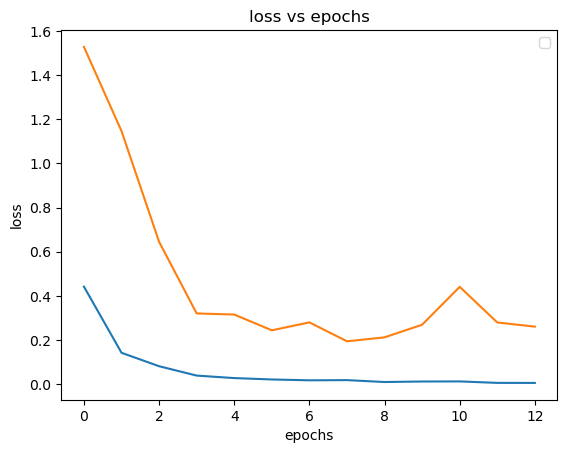

In [88]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss vs epochs')
plt.legend()
plt.show()

In [90]:
model.save("brain_tumor_Mobilenet.keras")

In [309]:
model.save("brain_tumor_resnet50.keras")